<a href="https://colab.research.google.com/github/DavidPardo3718/NutriGymDP/blob/main/E5_Carniceria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [20]:
np.random.seed(42)

fechas = pd.date_range(start="2025-01-01", periods=60)
productos = ["Res - Bistec", "Res - Molida", "Pollo - Pechuga", "Pollo - Pierna", "Cerdo - Costilla"]
vendedores = ["Juan", "Ana", "Pedro"]
metodos_pago = ["Efectivo", "Tarjeta", "Transferencia"]

In [21]:
data = []
for fecha in fechas:
    for _ in range(np.random.randint(15, 30)):  # ventas por día
        producto = np.random.choice(productos)
        cantidad = np.random.randint(1, 5)
        precio_unitario = np.random.randint(60, 150) if "Res" in producto else np.random.randint(40, 100)
        ingreso = cantidad * precio_unitario
        vendedor = np.random.choice(vendedores)
        metodo = np.random.choice(metodos_pago, p=[0.6, 0.3, 0.1])  # más efectivo
        data.append([fecha, producto, cantidad, ingreso, vendedor, metodo])

In [22]:
df = pd.DataFrame(data, columns=["Fecha", "Producto", "Cantidad", "Ingreso", "Vendedor", "Metodo_Pago"])
df.head()

,Fecha,Producto,Cantidad,Ingreso,Vendedor,Metodo_Pago
0,2025-01-01,Pollo - Pierna,1,54,Pedro,Tarjeta
1,2025-01-01,Cerdo - Costilla,3,291,Pedro,Efectivo
2,2025-01-01,Pollo - Pechuga,4,368,Pedro,Efectivo
3,2025-01-01,Res - Molida,4,356,Ana,Efectivo
4,2025-01-01,Pollo - Pierna,1,72,Ana,Efectivo


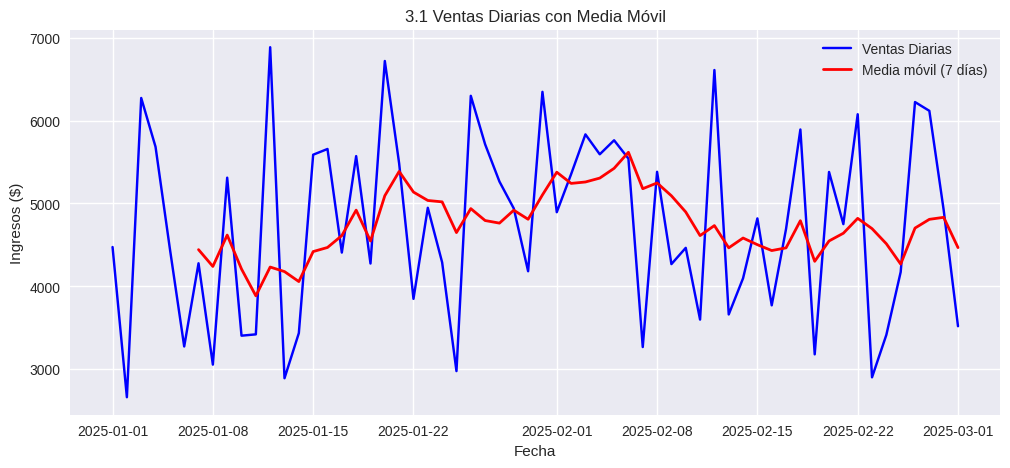

In [23]:
ventas_diarias = df.groupby("Fecha")["Ingreso"].sum()

plt.figure(figsize=(12,5))
plt.plot(ventas_diarias.index, ventas_diarias.values, label="Ventas Diarias", color="blue")
plt.plot(ventas_diarias.rolling(7).mean(), label="Media móvil (7 días)", color="red", linewidth=2)
plt.title("3.1 Ventas Diarias con Media Móvil")
plt.xlabel("Fecha")
plt.ylabel("Ingresos ($)")
plt.legend()
plt.show()

/tmp/ipython-input-451312318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.values, y=top_productos.index, palette="viridis")


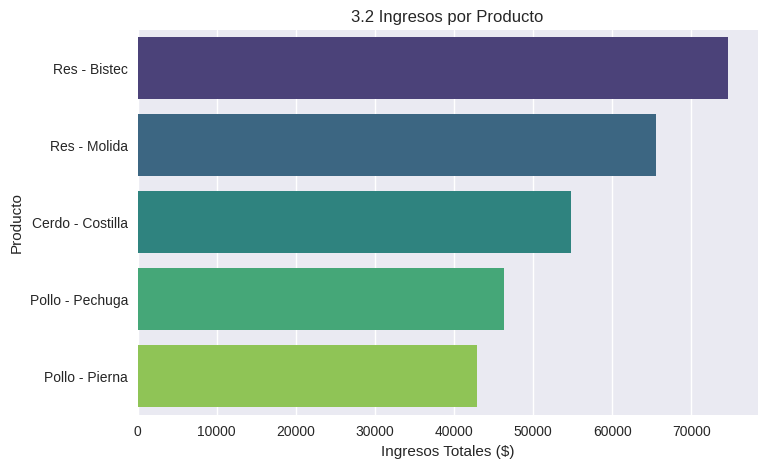

In [24]:
top_productos = df.groupby("Producto")["Ingreso"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=top_productos.values, y=top_productos.index, palette="viridis")
plt.title("3.2 Ingresos por Producto")
plt.xlabel("Ingresos Totales ($)")
plt.ylabel("Producto")
plt.show()

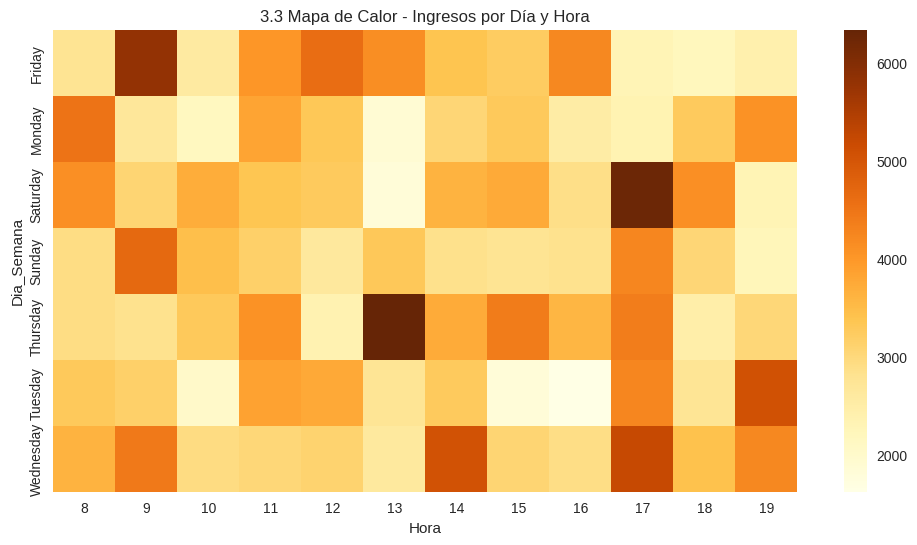

In [25]:
df["Dia_Semana"] = df["Fecha"].dt.day_name()
df["Hora"] = np.random.randint(8, 20, size=len(df))  # horas simuladas de atención (8 AM a 8 PM)

heatmap_data = df.pivot_table(values="Ingreso", index="Dia_Semana", columns="Hora", aggfunc="sum").fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrBr")
plt.title("3.3 Mapa de Calor - Ingresos por Día y Hora")
plt.show()

/tmp/ipython-input-3139232094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ingresos_vendedor.index, y=ingresos_vendedor.values, palette="coolwarm")


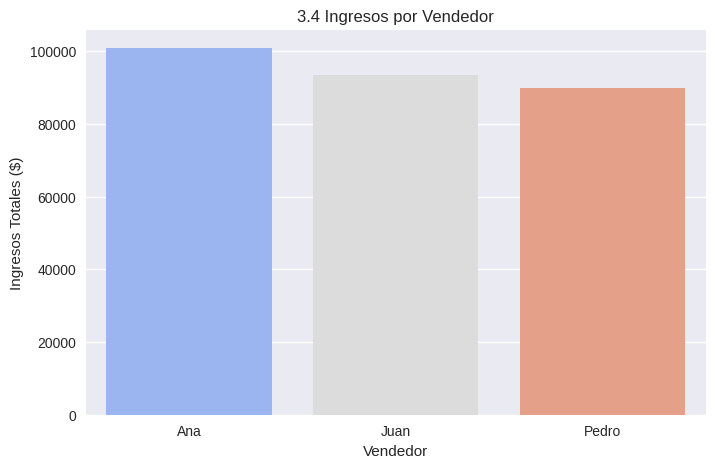

In [26]:
ingresos_vendedor = df.groupby("Vendedor")["Ingreso"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=ingresos_vendedor.index, y=ingresos_vendedor.values, palette="coolwarm")
plt.title("3.4 Ingresos por Vendedor")
plt.xlabel("Vendedor")
plt.ylabel("Ingresos Totales ($)")
plt.show()

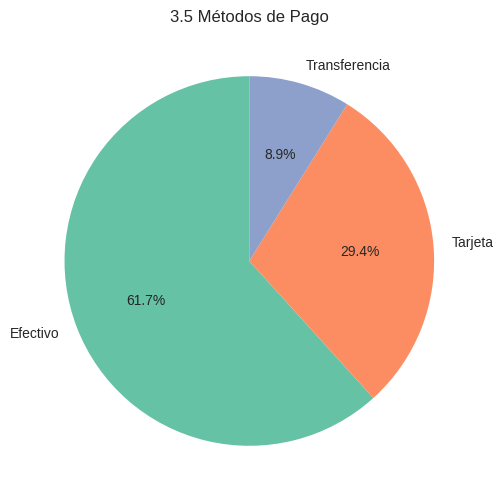

In [27]:
metodos_pago = df["Metodo_Pago"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(metodos_pago.values, labels=metodos_pago.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
plt.title("3.5 Métodos de Pago")
plt.show()

In [28]:
import plotly.express as px
import plotly.graph_objects as go

def grafica_ventas_diarias(df):
    daily = df.groupby("Fecha")["Ingreso"].sum().reset_index()
    fig = px.line(daily, x="Fecha", y="Ingreso", title="Ventas Diarias")
    fig.add_trace(go.Scatter(x=daily["Fecha"], y=daily["Ingreso"].rolling(7).mean(),
                             mode="lines", name="Media móvil 7 días", line=dict(dash="dash")))
    fig.show()

def grafica_top_productos(df):
    top_prod = df.groupby("Producto")["Ingreso"].sum().sort_values(ascending=False).reset_index()
    fig = px.bar(top_prod.head(10), x="Ingreso", y="Producto", orientation='h', title="Top 10 Productos")
    fig.show()

def grafica_metodo_pago(df):
    pagos = df.groupby("Metodo_Pago")["Ingreso"].sum().reset_index()
    fig = px.pie(pagos, names="Metodo_Pago", values="Ingreso", hole=0.4, title="Métodos de Pago")
    fig.show()


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

def grafica_ventas_diarias_static(df):
    ventas_diarias = df.groupby("Fecha")["Ingreso"].sum()
    plt.figure(figsize=(12,5))
    plt.plot(ventas_diarias.index, ventas_diarias.values, label="Ventas Diarias")
    plt.plot(ventas_diarias.rolling(7).mean(), label="Media móvil 7 días", linestyle="--", color="red")
    plt.title("Ventas Diarias")
    plt.xlabel("Fecha")
    plt.ylabel("Ingresos ($)")
    plt.legend()
    plt.show()

def grafica_top_productos_static(df):
    top_prod = df.groupby("Producto")["Ingreso"].sum().sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=top_prod.values, y=top_prod.index, palette="viridis")
    plt.title("Top Productos")
    plt.xlabel("Ingresos ($)")
    plt.show()


In [30]:
def interpretar_ventas_diarias():
    return "- Observa picos en fines de semana. La media móvil suaviza variaciones y muestra tendencia."

def interpretar_top_productos():
    return "- Los cortes de res son los más rentables. Priorizar stock y promociones de pollo."

def interpretar_metodo_pago():
    return "- Efectivo predomina, conviene incentivar pagos electrónicos para reducir riesgo de caja."


In [31]:
grafica_ventas_diarias(df)

In [32]:
grafica_top_productos(df)

In [33]:
grafica_metodo_pago(df)

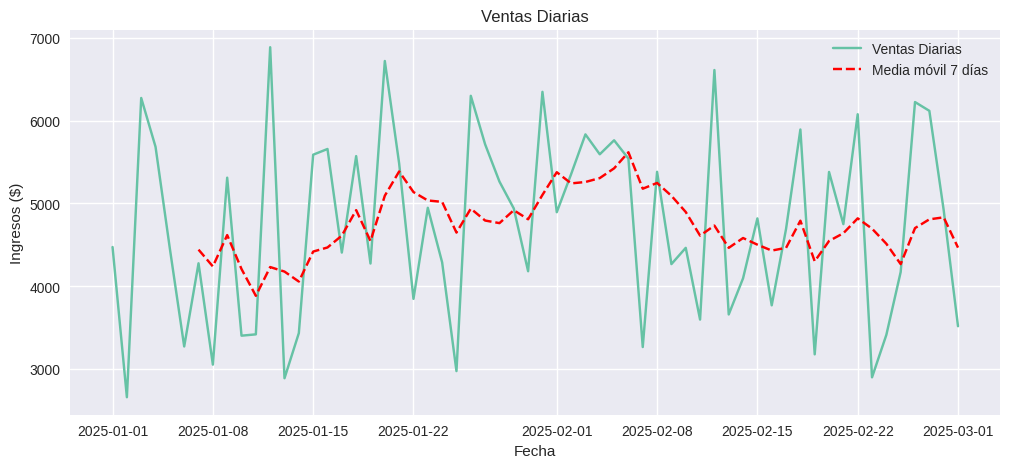

In [34]:
grafica_ventas_diarias_static(df)

/tmp/ipython-input-2694593389.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




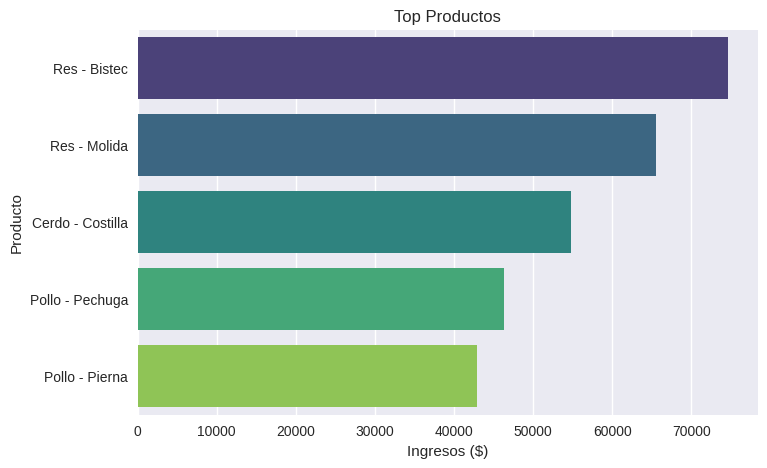

In [35]:
grafica_top_productos_static(df)